In [26]:
!pip install tensorflow==2.20.0 protobuf==5.29.1 pennylane -q

In [29]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import logging
logging.disable(logging.WARNING)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import pennylane as qml
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2
import time
import pickle

print("TensorFlow:", tf.__version__)
print("PennyLane:", qml.__version__)

TensorFlow: 2.20.0
PennyLane: 0.45.1


In [30]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_dir = '/content/drive/MyDrive/qcnn_checkpoints_10class'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = f"{checkpoint_dir}/qcnn_weights_10class.pkl"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
n_train = 500       # training data
n_val = 100          # validation data (checked every epoch, separate from training)
n_test = 100         # test data (only used once, at the end)

x_train = x_train_full[:n_train].astype("float32") / 255.0
y_train = y_train_full[:n_train]

x_val = x_train_full[n_train:n_train+n_val].astype("float32") / 255.0
y_val = y_train_full[n_train:n_train+n_val]

x_test = x_test_full[:n_test].astype("float32") / 255.0
y_test = y_test_full[:n_test]

x_train = tf.image.resize(x_train[..., np.newaxis], (8, 8)).numpy()
x_val   = tf.image.resize(x_val[..., np.newaxis], (8, 8)).numpy()
x_test  = tf.image.resize(x_test[..., np.newaxis], (8, 8)).numpy()

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

Train: (500, 8, 8, 1) Val: (100, 8, 8, 1) Test: (100, 8, 8, 1)


In [32]:
def extract_patches(images):
    n = images.shape[0]
    patches = np.zeros((n, 4, 16), dtype=np.float32)
    for idx in range(n):
        img = images[idx, :, :, 0]
        p = 0
        for i in range(0, 8, 4):
            for j in range(0, 8, 4):
                patches[idx, p] = img[i:i+4, j:j+4].flatten()
                p += 1
    return patches

x_train_patches = extract_patches(x_train)
x_val_patches = extract_patches(x_val)
x_test_patches = extract_patches(x_test)

print(x_train_patches.shape, x_val_patches.shape, x_test_patches.shape)


(500, 4, 16) (100, 4, 16) (100, 4, 16)


In [33]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def conv_block(params, wires):
    """RY rotation -> CNOT entanglement -> RZ rotation."""
    for i, w in enumerate(wires):
        qml.RY(params[i], wires=w)
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    for i, w in enumerate(wires):
        qml.RZ(params[len(wires) + i], wires=w)

def pool_block(params, wires_in, wires_out):
    """CRZ entangles discarded qubit into active qubit, then flips it."""
    for i, (w_in, w_out) in enumerate(zip(wires_in, wires_out)):
        qml.CRZ(params[i], wires=[w_in, w_out])
        qml.PauliX(wires=w_in)

In [34]:
@qml.qnode(dev, interface="tf", diff_method="backprop")
def qcnn_patch_circuit(inputs, conv1_w, pool1_w, conv2_w):
    # Amplitude Embedding: packs 16 pixel values into 4 qubits
    qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.0)

    # Quantum Convolution Block 1 (all 4 qubits)
    conv_block(conv1_w, wires=[0, 1, 2, 3])

    # Quantum Pooling Block 1 (4 qubits -> 3 active qubits)
    pool_block(pool1_w, wires_in=[0], wires_out=[1])

    # Quantum Convolution Block 2 (remaining 3 active qubits)
    conv_block(conv2_w, wires=[1,2, 3])

    # Pauli-Z Measurement on both remaining qubits (3 outputs, for richer features)
    return [qml.expval(qml.PauliZ(1)), qml.expval(qml.PauliZ(2)),qml.expval(qml.PauliZ(3))]

In [35]:
conv1_w = tf.Variable(np.random.uniform(0, 2*np.pi, 8), dtype=tf.float64, trainable=True)
pool1_w = tf.Variable(np.random.uniform(0, 2*np.pi, 1), dtype=tf.float64, trainable=True)  # 1 pooled pair now
conv2_w = tf.Variable(np.random.uniform(0, 2*np.pi, 6), dtype=tf.float64, trainable=True)   # 3 qubits x 2 rotations

fc_weights = tf.Variable(tf.random.normal((12, 10), stddev=0.1, dtype=tf.float64), trainable=True)  # 4 patches x 3 outputs = 12
fc_bias = tf.Variable(tf.zeros(10, dtype=tf.float64), trainable=True)

all_trainable_vars = [conv1_w, pool1_w, conv2_w, fc_weights, fc_bias]

def forward(x_patches):
    batch_outputs = []
    for img in x_patches:
        patch_feats = []
        for patch in img:
            patch_safe = patch + 1e-8
            out = qcnn_patch_circuit(patch_safe, conv1_w, pool1_w, conv2_w)
            out_real = [tf.math.real(tf.cast(o, tf.complex128)) for o in out]
            patch_feats.append(tf.stack(out_real))
        img_feat = tf.reshape(tf.stack(patch_feats), [-1])  # (12,) = 4 patches x 3 outputs
        batch_outputs.append(img_feat)
    features = tf.stack(batch_outputs)
    logits = tf.matmul(tf.cast(features, tf.float64), fc_weights) + fc_bias
    return tf.nn.softmax(logits)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        preds = forward(x_batch)
        loss = tf.keras.losses.sparse_categorical_crossentropy(
            tf.cast(y_batch, tf.int32), preds
        )
        loss = tf.reduce_mean(loss)
    grads = tape.gradient(loss, all_trainable_vars)
    optimizer.apply_gradients(zip(grads, all_trainable_vars))
    return loss

def evaluate(x_patches_set, y_set):
    preds = forward(x_patches_set)
    pred_labels = tf.argmax(preds, axis=1).numpy()
    acc = np.mean(pred_labels == y_set)
    return acc
def compute_loss(x_patches_set, y_set):
    preds = forward(x_patches_set)
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        tf.cast(y_set, tf.int32), preds
    )
    return tf.reduce_mean(loss).numpy()

In [36]:
def save_checkpoint(epoch, train_hist, val_hist, val_loss_hist, test_hist, loss_hist):
    checkpoint = {
        "epoch": epoch,
        "conv1_w": conv1_w.numpy(), "pool1_w": pool1_w.numpy(), "conv2_w": conv2_w.numpy(),
        "fc_weights": fc_weights.numpy(), "fc_bias": fc_bias.numpy(),
        "train_acc_history": train_hist, "val_acc_history": val_hist,
        "val_loss_history": val_loss_hist, "test_acc_history": test_hist, "loss_history": loss_hist,
    }
    with open(checkpoint_path, "wb") as f:
        pickle.dump(checkpoint, f)
    print(f"💾 Checkpoint saved (epoch {epoch})")

def load_checkpoint():
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "rb") as f:
            checkpoint = pickle.load(f)
        conv1_w.assign(checkpoint["conv1_w"]); pool1_w.assign(checkpoint["pool1_w"]); conv2_w.assign(checkpoint["conv2_w"])
        fc_weights.assign(checkpoint["fc_weights"]); fc_bias.assign(checkpoint["fc_bias"])
        print(f"✅ Checkpoint loaded — resuming from epoch {checkpoint['epoch']+1}")
        return (checkpoint["epoch"] + 1,
                checkpoint.get("train_acc_history", []), checkpoint.get("val_acc_history", []),
                checkpoint.get("val_loss_history", []), checkpoint.get("test_acc_history", []),
                checkpoint.get("loss_history", []))
    else:
        print("ℹ️ No checkpoint found — starting fresh")
        return 0, [], [], [], [], []

In [37]:
import os
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("Checkpoint deleted")

print("Confirm gone:", os.path.exists(checkpoint_path))  # should print False

Checkpoint deleted
Confirm gone: False


In [38]:
epochs = 10
batch_size = 32

start_epoch, train_acc_history, val_acc_history, val_loss_history, test_acc_history, loss_history = load_checkpoint()

print("🚀 Training started...\n")
overall_start = time.time()

for epoch in range(start_epoch, epochs):
    epoch_start = time.time()

    print(f"🔵 Entering training loop for epoch {epoch+1}/{epochs}...")
    perm = np.random.permutation(len(x_train_patches))
    x_shuf = x_train_patches[perm]
    y_shuf = y_train[perm]

    epoch_loss = 0
    n_batches = 0
    for i in range(0, len(x_shuf), batch_size):
        x_batch = x_shuf[i:i+batch_size]
        y_batch = y_shuf[i:i+batch_size]
        loss = train_step(x_batch, y_batch)
        epoch_loss += loss.numpy()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    if np.isnan(avg_loss):
        print("⚠️ NaN detected — stopping early.")
        break

    print(f"🟢 Entering validation loop for epoch {epoch+1}/{epochs}...")
    val_acc = evaluate(x_val_patches, y_val)
    val_loss = compute_loss(x_val_patches, y_val)

    print(f"🟠 Entering testing loop for epoch {epoch+1}/{epochs}...")
    train_acc = evaluate(x_train_patches, y_train)
    test_acc = evaluate(x_test_patches, y_test)

    epoch_time = time.time() - epoch_start

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)
    test_acc_history.append(test_acc)
    loss_history.append(avg_loss)

    print(f"✅ Epoch {epoch+1:2d} done | train_loss={avg_loss:.4f} | val_loss={val_loss:.4f} | "
          f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | test_acc={test_acc:.3f} | time={epoch_time:.1f}s")

    save_checkpoint(epoch, train_acc_history, val_acc_history, val_loss_history, test_acc_history, loss_history)
    print()

total_time = time.time() - overall_start
print(f"🏁 Training complete. Total time: {total_time/60:.1f} min")

ℹ️ No checkpoint found — starting fresh
🚀 Training started...

🔵 Entering training loop for epoch 1/10...
🟢 Entering validation loop for epoch 1/10...
🟠 Entering testing loop for epoch 1/10...
✅ Epoch  1 done | train_loss=2.1678 | val_loss=2.1322 | train_acc=0.348 | val_acc=0.270 | test_acc=0.290 | time=623.9s
💾 Checkpoint saved (epoch 0)

🔵 Entering training loop for epoch 2/10...
🟢 Entering validation loop for epoch 2/10...
🟠 Entering testing loop for epoch 2/10...
✅ Epoch  2 done | train_loss=1.9467 | val_loss=2.0198 | train_acc=0.446 | val_acc=0.330 | test_acc=0.440 | time=588.9s
💾 Checkpoint saved (epoch 1)

🔵 Entering training loop for epoch 3/10...
🟢 Entering validation loop for epoch 3/10...
🟠 Entering testing loop for epoch 3/10...
✅ Epoch  3 done | train_loss=1.7569 | val_loss=1.8974 | train_acc=0.522 | val_acc=0.430 | test_acc=0.450 | time=576.6s
💾 Checkpoint saved (epoch 2)

🔵 Entering training loop for epoch 4/10...
🟢 Entering validation loop for epoch 4/10...
🟠 Entering t

In [39]:
final_test_acc = evaluate(x_test_patches, y_test)
print(f"Final test accuracy: {final_test_acc:.4f}")

Final test accuracy: 0.4900


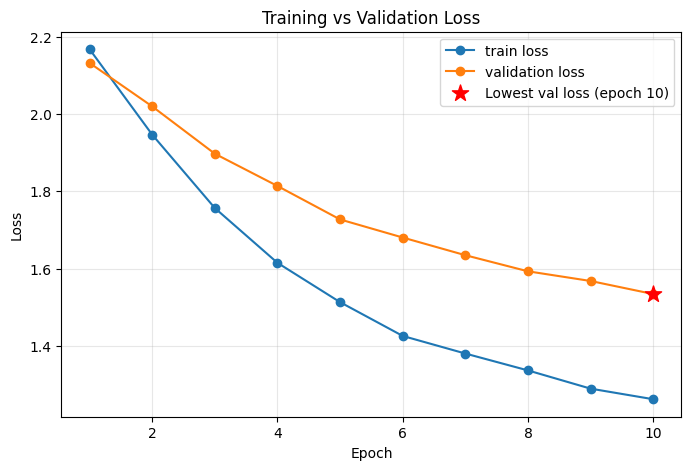

In [40]:
epochs_list = list(range(1, len(loss_history) + 1))
best_epoch_idx = int(np.argmin(val_loss_history))
best_epoch_num = best_epoch_idx + 1

plt.figure(figsize=(8, 5))
plt.plot(epochs_list, loss_history, label="train loss", marker='o')
plt.plot(epochs_list, val_loss_history, label="validation loss", marker='o')
plt.scatter([best_epoch_num], [val_loss_history[best_epoch_idx]],
            color='red', s=150, marker='*', zorder=5,
            label=f"Lowest val loss (epoch {best_epoch_num})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

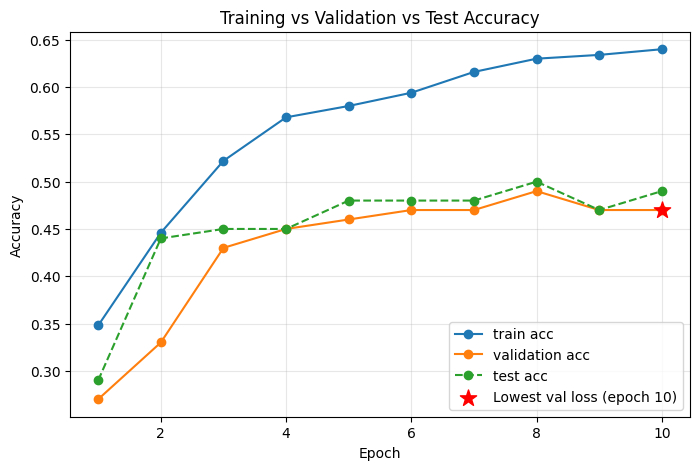

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, train_acc_history, label="train acc", marker='o')
plt.plot(epochs_list, val_acc_history, label="validation acc", marker='o')
plt.plot(epochs_list, test_acc_history, label="test acc", marker='o', linestyle='--')
plt.scatter([best_epoch_num], [val_acc_history[best_epoch_idx]],
            color='red', s=150, marker='*', zorder=5,
            label=f"Lowest val loss (epoch {best_epoch_num})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation vs Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()